$Initial Approach$  - I am taking one random point and solving by taking random guess for theta and theta' between (-1 ,1) until it is converged then i am using this solution as initial guess for adjacent point of this randomly selected point . After that I am taking another random point following the same procedure as for previuos one and so on until all point in mesh grid is solved 

In [1]:
import numpy as np
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import random  # Ensure random is imported
import itertools

# Define the parameters
l = 1.0  # Length
# h_min, h_max = -80, 0.5  # Range for h
# v_min, v_max = -45, 45 # Range for v
h_min, h_max = -27, 0.5  # Range for h
v_min, v_max = -16, 16
num_points = 60  # Number of grid points in each direction

# Create meshgrid for h and v
h_values = np.linspace(h_min, h_max, num_points)
v_values = np.linspace(v_min, v_max, num_points)
H, V = np.meshgrid(h_values, v_values)
grid_points = np.column_stack((H.ravel(), V.ravel()))

# Function to define the ODE
def ode_system(s, y, h, v):
    theta, theta_prime = y  # Unpack the solution vector
    dtheta_ds = theta_prime
    dtheta_prime_ds = h * np.sin(theta) - v * np.cos(theta)
    return np.array([dtheta_ds, dtheta_prime_ds])

# Boundary conditions function
def boundary_conditions(ya, yb):
    return np.array([ya[0], yb[1]])  # theta(0) = 0 and theta'(l) = 0

# Function to solve ODE for given h and v
def solve_bvp_for_hv(h, v, initial_guess):
    s = np.linspace(0, l, 300)  # Discretize the interval
    y_guess = initial_guess  # Use provided initial guess

    # Pass h and v directly to the ode_system
    solution = solve_bvp(lambda s, y: ode_system(s, y, h, v), boundary_conditions, s, y_guess)
    
    if solution.success:
        return solution.success, solution
    else:
        return False, None

# List to store solutions
solutions = []
s = np.linspace(0 , l , 300)

# Solve for the closest point to (0, 0)
closest_index = np.argmin(np.linalg.norm(grid_points, axis=1))
h_closest, v_closest = grid_points[closest_index]
initial_guess_closest = np.zeros((2, len(s)))  # Initial guess: theta = 0, theta' = 0
bl , solution_closest = solve_bvp_for_hv(h_closest, v_closest, initial_guess_closest)
print(bl)
# Store solved points to avoid redundancy
solved_points = set()
solved_points_list = []
#print("closest index :" , closest_index)

# Store the solution for initial guess
theta_values = []
theta_prime_values = []
x_tip = []
y_tip = []  
valid_tips_count = 0
total_solved_points = 0
if bl:
    total_solved_points += 1  
    theta_values.append(solution_closest.sol(s)[0])
    theta_prime_values.append(solution_closest.sol(s)[1])   
    y1 = np.cos(theta_values[-1])
    y2 = np.sin(theta_values[-1])
    x = []
    y = []
    for j in range(len(s)):
        x.append(np.trapz(y1[:j+1], x=s[:j+1]))
        y.append(np.trapz(y2[:j+1], x=s[:j+1]))

    # Append final tip positions
    x_tip.append(x[-1])
    y_tip.append(y[-1])
    valid_tips_count += 1
    solutions.append((h_closest, v_closest, solution_closest))
    solved_points.add(closest_index)
    solved_points_list.append(closest_index)
    


# Directions for adjacent points (up, down, left, right)
adjacent_indices = [(-1, 0), (1, 0), (0, -1), (0, 1),  # up, down, left, right
                    (-1, -1), (-1, 1), (1, -1), (1, 1)]  # diagonals

# Solve for adjacent points
for dr, dc in adjacent_indices:
    adj_row = closest_index // num_points + dr
    adj_col = closest_index % num_points + dc
    if 0 <= adj_row < num_points and 0 <= adj_col < num_points:
        adj_index = adj_row * num_points + adj_col
        
        if adj_index not in solved_points:
            #print("adjacent index for closest index :" , adj_index)
            h_adj, v_adj = grid_points[adj_index]
            
            initial_guess_adjacent = np.zeros((2, len(s)))
            initial_guess_adjacent[0] = theta_values[0]  # Previous theta
            initial_guess_adjacent[1] = theta_prime_values[0]  # Previous theta'

            # Solve the BVP for the adjacent point
            bl , solution_adjacent = solve_bvp_for_hv(h_adj, v_adj, initial_guess_adjacent)
            if bl:
                total_solved_points += 1  
                # Store the solution for the adjacent point
                theta_values.append(solution_adjacent.sol(s)[0])
                theta_prime_values.append(solution_adjacent.sol(s)[1])
                y1 = np.cos(theta_values[-1])
                y2 = np.sin(theta_values[-1])
                x = []
                y = []
                for j in range(len(s)):
                    x.append(np.trapz(y1[:j+1], x=s[:j+1]))
                    y.append(np.trapz(y2[:j+1], x=s[:j+1]))
                
                # Append final tip positions
                x_tip.append(x[-1])
                y_tip.append(y[-1])
                valid_tips_count += 1
                solutions.append((h_adj, v_adj, solution_adjacent))
                solved_points.add(adj_index)
                solved_points_list.append(adj_index)
            # else:
            #     print(bl) # not required , if any adjacent solution is not converged then leave it as it is . it will be solved in another random index 

# Solve for remaining points
while len(solved_points) < len(grid_points):
    unsolved_indices = set(range(len(grid_points))) - solved_points
    random_index = np.random.choice(list(unsolved_indices))
    h_random, v_random = grid_points[random_index]
    #print("random index :" , random_index)
    # Function to generate a random initial guess
    def guess(n):
        return np.full((2, len(s)), n)

    # Generate random initial guess
    n = random.uniform(-1, 1)
    initial_guess_random = guess(n)  # Random initial guess

    # Attempt to solve the BVP
    bl, solution_random = solve_bvp_for_hv(h_random, v_random, initial_guess_random)
    
    # Keep trying until we find a solution
    while not bl:
        n = random.uniform(-1, 1)
        initial_guess_random = guess(n)
        bl, solution_random = solve_bvp_for_hv(h_random, v_random, initial_guess_random)
    if bl:
        total_solved_points += 1  
        # Store the solution for the random index
        theta = solution_random.sol(s)[0]
        theta_dash = solution_random.sol(s)[1]
        theta_values.append(solution_random.sol(s)[0])
        theta_prime_values.append(solution_random.sol(s)[1])
        y1 = np.cos(theta_values[-1])
        y2 = np.sin(theta_values[-1])
        x = []
        y = []
        for j in range(len(s)):
            x.append(np.trapz(y1[:j+1], x=s[:j+1]))
            y.append(np.trapz(y2[:j+1], x=s[:j+1]))
        
        # Append final tip positions
        x_tip.append(x[-1])
        y_tip.append(y[-1])
        valid_tips_count += 1
        solutions.append((h_random, v_random, solution_random))
        solved_points.add(random_index)
        solved_points_list.append(random_index)
    else:
        print(bl)

    # Now solve for adjacent points to this random point  
    for dr, dc in adjacent_indices:
        adj_row = random_index // num_points + dr
        adj_col = random_index % num_points + dc
        if 0 <= adj_row < num_points and 0 <= adj_col < num_points:
            adj_index = adj_row * num_points + adj_col
            #print("adjacent index for random index :" , adj_index)
            if adj_index not in solved_points:
                #print("adjacent index for random index :" , adj_index)
                h_adj, v_adj = grid_points[adj_index]
                
                initial_guess_adjacent = np.zeros((2, len(s)))
                initial_guess_adjacent[0] = theta  # Previous theta for random index (fixed for all adjacent points)
                initial_guess_adjacent[1] = theta_dash  # Previous theta' for random index ( fixed for all adjacent points)
        
                # Solve the BVP for the adjacent point
                bl , solution_adjacent = solve_bvp_for_hv(h_adj, v_adj, initial_guess_adjacent)
                if bl:
                    total_solved_points += 1
                    # Store the solution for the adjacent point
                    theta_values.append(solution_adjacent.sol(s)[0])
                    theta_prime_values.append(solution_adjacent.sol(s)[1])
                    y1 = np.cos(theta_values[-1])
                    y2 = np.sin(theta_values[-1])
                    x = []
                    y = []
                    for j in range(len(s)):
                        x.append(np.trapz(y1[:j+1], x=s[:j+1]))
                        y.append(np.trapz(y2[:j+1], x=s[:j+1]))
                    
                    # Append final tip positions
                    x_tip.append(x[-1])
                    y_tip.append(y[-1])
                    valid_tips_count += 1
                    solutions.append((h_adj, v_adj, solution_adjacent))
                    solved_points.add(adj_index)
                    solved_points_list.append(adj_index)
                # else:
                #     print(bl)        # not required , if any adjacent solution is not converged then leave it as it is . it will be solved in another random index 


# # # Output the results
h = []
v = []
for h_sol, v_sol, sol in solutions:
    h.append(h_sol)
    v.append(v_sol)
hv_pairs = list(zip(h, v))    
        # print(f"Failed to solve for h={h}, v={v}.")
print(f"Total solved points: {len(solved_points)}")
print(f"Valid tip positions: {valid_tips_count}")
print(f"Length of x_tip: {len(x_tip)}")
print(f"Length of y_tip: {len(y_tip)}")
print(f"Length of theta_values: {len(theta_values)}")
print(len(solved_points_list))

True
Total solved points: 3600
Valid tip positions: 3600
Length of x_tip: 3600
Length of y_tip: 3600
Length of theta_values: 3600
3600


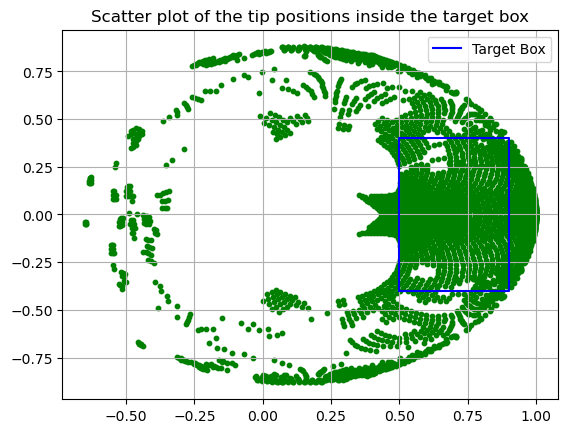

Number of points inside the box: 1241


In [2]:
plt.scatter(x_tip, y_tip, color='g', s=10, )
x_box = [0.5, 0.9, 0.9, 0.5, 0.5]
y_box = [-0.4, -0.4, 0.4, 0.4, -0.4]
plt.plot(x_box, y_box, 'b-', label='Target Box')
plt.title('Scatter plot of the tip positions inside the target box')
plt.grid(True)
plt.legend()
plt.show()
x_min, x_max = min(x_box), max(x_box)
y_min, y_max = min(y_box), max(y_box)

# Count how many points are inside the box
inside_box_count = 0
for x, y in zip(x_tip, y_tip):
    if x_min <= x <= x_max and y_min <= y <= y_max:
        inside_box_count += 1

print(f"Number of points inside the box: {inside_box_count}")

$Second Approach$- In this I am first solving for point (h , v) in mesh grid which is close to zero (0,0) by taking initial guess as (0 , 0) for theta and theta' , ( this step i am also following in first approch but not required) then solving for all adjacent points of this point (close to (0,0)).Then I am rendomly picking one solved point among all solved ponits and finding its neighbours and solving for it's neighbours by taking initial guess as solution of randomly picked solved points . Doing this untill all point in mesh grid is covered.


In [39]:
import numpy as np
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import random
from collections import Counter

random.seed(42) 
np.random.seed(42)

# Define the parameters
l = 1.0  # Length
h_min, h_max = -100, 100 # Range for h  ( h = 32 , v = 17)
v_min, v_max = -13 , 13
num_points = 70  # Number of grid points in each direction

# Create meshgrid for h and v
h_values = np.linspace(h_min, h_max, num_points)
v_values = np.linspace(v_min, v_max, num_points)
H, V = np.meshgrid(h_values, v_values)
grid_points = np.column_stack((H.ravel(), V.ravel()))

# Function to define the ODE
def ode_system(s, y, h, v):
    theta, theta_prime = y  # Unpack the solution vector
    dtheta_ds = theta_prime
    dtheta_prime_ds = h * np.sin(theta) - v * np.cos(theta)
    return np.array([dtheta_ds, dtheta_prime_ds])

# Boundary conditions function
def boundary_conditions(ya, yb):
    return np.array([ya[0], yb[1]])  # theta(0) = 0 and theta'(l) = 0

# Function to solve ODE for given h and v
def solve_bvp_for_hv(h, v, initial_guess):
    s = np.linspace(0, l, 300)  # Discretize the interval
    y_guess = initial_guess  # Use provided initial guess

    # Pass h and v directly to the ode_system
    solution = solve_bvp(lambda s, y: ode_system(s, y, h, v), boundary_conditions, s, y_guess)
    
    if solution.success:
        return solution.success, solution
    else:
        return False, None

# List to store solutions
solutions = []
s = np.linspace(0 , l , 300)

# Solve for the closest point to (0, 0)
closest_index = np.argmin(np.linalg.norm(grid_points, axis=1))
h_closest, v_closest = grid_points[closest_index]
print(h_closest , v_closest)
n = random.uniform(-1 ,1)
#initial_guess_closest = np.zeros((2, len(s)))  # Initial guess: theta = 0, theta' = 0
initial_guess_closest = np.full((2, len(s)), n)
bl , solution_closest = solve_bvp_for_hv(h_closest, v_closest, initial_guess_closest)
print(bl)

# Store solved points to avoid redundancy
solved_points = set()
solved_points_list = []

# Store the solution in dictionaries
theta_dict = {}
theta_prime_dict = {}
x_tip = []
y_tip = []  
valid_tips_count = 0
total_solved_points = 0

if bl:
    total_solved_points += 1  
    theta_dict[closest_index] = solution_closest.sol(s)[0]
    theta_prime_dict[closest_index] = solution_closest.sol(s)[1]   
    y1 = np.cos(theta_dict[closest_index])
    y2 = np.sin(theta_dict[closest_index])
    x = []
    y = []
    for j in range(len(s)):
        x.append(np.trapezoid(y1[:j+1], x=s[:j+1]))
        y.append(np.trapezoid(y2[:j+1], x=s[:j+1]))

    # Append final tip positions
    x_tip.append(x[-1])
    y_tip.append(y[-1])
    valid_tips_count += 1
    solutions.append((h_closest, v_closest, solution_closest))
    solved_points.add(closest_index)
    solved_points_list.append(closest_index)

# Directions for adjacent points (up, down, left, right)
adjacent_indices = [(-1, 0), (1, 0), (0, -1), (0, 1),  # up, down, left, right
                    (-1, -1), (-1, 1), (1, -1), (1, 1)]
def get_adjacent_unsolved_points(index , solved_points):
    row, col = index // num_points, index % num_points
    unsolved_adjacent = []
    for dr, dc in adjacent_indices:
        adj_row, adj_col = row + dr, col + dc
        if 0 <= adj_row < num_points and 0 <= adj_col < num_points:
            adj_index = adj_row * num_points + adj_col
            if adj_index not in solved_points:
                unsolved_adjacent.append(adj_index)
    return unsolved_adjacent
# solution must be found out for closest point then only code will proceed further 
# Some time if num_points is small then solution may not converge for closest point , in that case increase number of points in mesh grid
indices =[]
indices.append(closest_index)
# Solve for remaining points
while len(solved_points) < len(grid_points):
    keys = list(theta_dict.keys())
    index = random.choice(keys)
    #indices.append(index)
    theta_guess = theta_dict[index]
    theta_prime_guess = theta_prime_dict[index]
    unsolved_adj_indices = get_adjacent_unsolved_points(index , solved_points)
    if unsolved_adj_indices:
        for i in (unsolved_adj_indices):
            indices.append(i)
            h_adj, v_adj = grid_points[i]
            initial_guess_adjacent = np.zeros((2, len(s)))
            initial_guess_adjacent[0] = theta_guess
            initial_guess_adjacent[1] = theta_prime_guess
            bl, solution_random = solve_bvp_for_hv(h_adj, v_adj, initial_guess_adjacent)
            if bl:
                total_solved_points += 1  
                # Store the solution for the random index
                theta_dict[i] = solution_random.sol(s)[0]
                theta_prime_dict[i] = solution_random.sol(s)[1]
                y1 = np.cos(theta_dict[i])
                y2 = np.sin(theta_dict[i])
                x = []
                y = []
                for j in range(len(s)):
                    x.append(np.trapezoid(y1[:j+1], x=s[:j+1]))
                    y.append(np.trapezoid(y2[:j+1], x=s[:j+1]))
                
                # Append final tip positions
                x_tip.append(x[-1])
                y_tip.append(y[-1])
                valid_tips_count += 1
                solutions.append((h_adj, v_adj, solution_random))
                solved_points.add(i)
                solved_points_list.append(i)
x_tip = x_tip
y_tip = y_tip
theta_dict = theta_dict
theta_prime_dict = theta_prime_dict
print(f"Total solved points: {len(solved_points)}")
print(f"Valid tip positions: {valid_tips_count}")
print(f"Length of x_tip: {len(x_tip)}")
print(f"Length of y_tip: {len(y_tip)}")
print(f"Length of theta_values: {len(theta_dict)}")
print(len(solved_points_list))
print(keys[0])
print(closest_index)
#print(indices)

-1.4492753623188435 -0.18840579710144922
True
Total solved points: 4900
Valid tip positions: 4900
Length of x_tip: 4900
Length of y_tip: 4900
Length of theta_values: 4900
4900
2414
2414


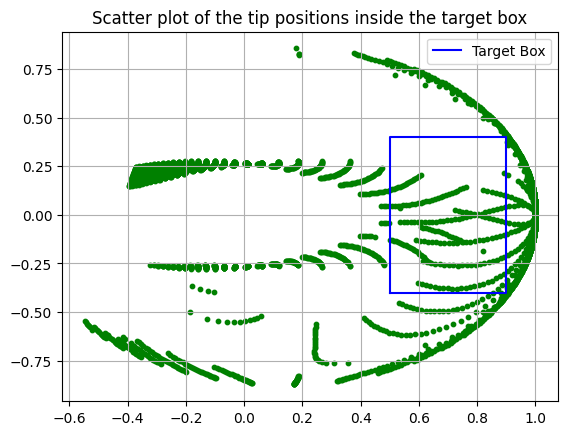

Number of points inside the box: 201
Number of duplicate points: 0
Duplicate points and their counts: {}


In [40]:
plt.scatter(x_tip, y_tip, color='g', s=10, )
x_box = [0.5, 0.9, 0.9, 0.5, 0.5]
y_box = [-0.4, -0.4, 0.4, 0.4, -0.4]
plt.plot(x_box, y_box, 'b-', label='Target Box')
plt.title('Scatter plot of the tip positions inside the target box')
plt.grid(True)
plt.legend()
plt.show()
x_min, x_max = min(x_box), max(x_box)
y_min, y_max = min(y_box), max(y_box)

# Count how many points are inside the box
inside_box_count = 0
for x, y in zip(x_tip, y_tip):
    if x_min <= x <= x_max and y_min <= y <= y_max:
        inside_box_count += 1

print(f"Number of points inside the box: {inside_box_count}")
coordinates = list(zip(x_tip, y_tip))

# Count occurrences of each coordinate
coordinate_counts = Counter(coordinates)

# Find duplicates
duplicates = {coord: count for coord, count in coordinate_counts.items() if count > 1}

# Output duplicate points and their counts
print(f"Number of duplicate points: {len(duplicates)}")
print("Duplicate points and their counts:", duplicates)
